# Transfer Learning USAD → SIATA (v3 — Mejoras aplicadas)
**Sensor 68 — Temperatura ambiente (1 canal)**

Versión mejorada sobre v2, con las siguientes correcciones y adiciones:

| Mejora | v2 | v3 |
|--------|----|----|
| Bottleneck `z_size` | 100 (sin compresión real) | **4** (compresión 3:1) |
| Learning rate | 1e-3 | **1e-4** (evita destruir pesos TL) |
| Batch size | 512 | **128** (mejor generalización) |
| Weight decay | — | **1e-5** (regularización L2) |
| Freeze schedule | — | **20 épocas freeze** en encoder.linear1 |
| Selección umbral | Solo F1-PR | **Youden + F1 + Percentil p99** |
| Ablation study | — | **Scratch vs TL vs TL+freeze** |

**Pipeline:**
1. Setup — clonar repo e instalar dependencias
2. Config — hiperparámetros
3. DataModule — carga, normalización Z-score, splits por fecha
4. Funciones helper — reconstrucción, error, gráficas (estilo Monografia)
5. Transfer Learning — sub-matriz del encoder pre-entrenado
6. Trainer — fine-tuning USAD con freeze schedule
7. Análisis completo — curva PR, múltiples umbrales, error de reconstrucción
8. Evaluación complementaria — ROC, histogramas, matrices de confusión
9. Ablation Study — Scratch vs TL vs TL+freeze
10. Guardar modelo

## 0. Setup — Clonar repo e instalar dependencias

In [1]:
import os, sys

REPO_URL = "https://github.com/ronvas234/data-science-monograph.git"
REPO_DIR = "data-science-monograph"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL}")

os.chdir(REPO_DIR)

USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

print(f"CWD: {os.getcwd()}")
print(f"USAD path en sys.path: {USAD_MODULE_PATH}")

os.system("pip install torch scikit-learn pandas matplotlib numpy seaborn plotly -q")

CWD: /content/data-science-monograph
USAD path en sys.path: /content/data-science-monograph/modelos/usad


0

## 1. Config — Única fuente de verdad para hiperparámetros

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    data_path: str = "modelos/usad/data/plan_a/68.csv"
    pretrained_path: str = "modelos/usad/model.pth"
    window_size: int = 12       # timesteps por ventana (12 minutos)
    w_size_new: int = 12        # 1 canal × 12 timesteps
    z_size_new: int = 4         # bottleneck — compresión real (12→6→3→4 vs 12→6→3→100)
    epochs: int = 100
    batch_size: int = 128       # menor batch → más actualizaciones/época, mejor generalización
    alpha: float = 0.5
    beta: float = 0.5
    learning_rate: float = 1e-4  # LR baja para no destruir pesos transferidos
    weight_decay: float = 1e-5   # regularización L2
    freeze_epochs: int = 20      # épocas con encoder.linear1 congelado (warm-up)
    random_seed: int = 42
    fecha_inicio: str = "2023-01-01"
    fecha_fin: str = "2023-06-30"

config = Config()
print(config)
print(f"\nArquitectura encoder: {config.w_size_new} → {config.w_size_new//2} → {config.w_size_new//4} → {config.z_size_new}")
print(f"Compresión real: {config.w_size_new}:{config.z_size_new} = {config.w_size_new/config.z_size_new:.1f}x")

Config(data_path='modelos/usad/data/plan_a/68.csv', pretrained_path='modelos/usad/model.pth', window_size=12, w_size_new=12, z_size_new=4, epochs=100, batch_size=128, alpha=0.5, beta=0.5, learning_rate=0.0001, weight_decay=1e-05, freeze_epochs=20, random_seed=42, fecha_inicio='2023-01-01', fecha_fin='2023-06-30')

Arquitectura encoder: 12 → 6 → 3 → 4
Compresión real: 12:4 = 3.0x


## 2. DataModule — Carga, normalización Z-score y splits por fecha

Replicando exactamente el enfoque de `Monografia_S_RNN_Mask.ipynb`:
- Filtro de fechas: `2023-01-01` → `2023-06-30`
- Splits por posición: 70% Train / 15% Val / 15% Test
- Normalización Z-score ajustada **solo** sobre datos normales (`flag==0`) del train

In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# ── Carga de datos ────────────────────────────────────────────────────────────
data_raw = pd.read_csv(config.data_path)
data_raw['fecha_hora'] = pd.to_datetime(data_raw['fecha_hora'], format='%Y-%m-%d %H:%M:%S')
data_raw = data_raw.set_index('fecha_hora')

# Eliminar columna Split si existe (no se usa en este esquema)
if 'Split' in data_raw.columns:
    data_raw.drop(columns=['Split'], inplace=True)

print(f"Total raw antes de filtro: {len(data_raw):,} puntos")
print(f"Rango raw: {data_raw.index.min()} → {data_raw.index.max()}")

# ── Filtro de fechas (igual que Monografia) ───────────────────────────────────
data_raw = data_raw[
    (data_raw.index >= config.fecha_inicio) &
    (data_raw.index <= config.fecha_fin)
]
print(f"\nTotal después del filtro ({config.fecha_inicio} → {config.fecha_fin}): {len(data_raw):,} puntos")

# ── Splits 70/15/15 por posición (igual que Monografia celda 14) ──────────────
n = len(data_raw)
train_size = int(n * 0.70)
val_size   = int(n * 0.15)

data_train = data_raw[:train_size]
data_val   = data_raw[train_size:train_size + val_size]
data_test  = data_raw[train_size + val_size:]

print(f"\nTrain: {data_train.index.min().date()} → {data_train.index.max().date()} ({len(data_train):,} pts)")
print(f"Val:   {data_val.index.min().date()} → {data_val.index.max().date()}   ({len(data_val):,} pts)")
print(f"Test:  {data_test.index.min().date()} → {data_test.index.max().date()}  ({len(data_test):,} pts)")
print(f"\nAnomalías — Train: {data_train['flag'].sum()} | Val: {data_val['flag'].sum()} | Test: {data_test['flag'].sum()}")

Total raw antes de filtro: 83,480 puntos
Rango raw: 2023-03-29 00:00:00 → 2023-07-05 23:59:00

Total después del filtro (2023-01-01 → 2023-06-30): 74,841 puntos

Train: 2023-03-29 → 2023-06-14 (52,388 pts)
Val:   2023-06-14 → 2023-06-22   (11,226 pts)
Test:  2023-06-22 → 2023-06-30  (11,227 pts)

Anomalías — Train: 720 | Val: 283 | Test: 315


In [4]:
# ── Normalización Z-score (igual que Monografia celda 19) ─────────────────────
# Ajustar SOLO sobre datos normales (flag==0) del train
media = data_train[data_train['flag'] == 0]['t'].mean()
std   = data_train[data_train['flag'] == 0]['t'].std()

print(f"Media train (flag=0): {media:.2f}°C")
print(f"Std train  (flag=0): {std:.2f}°C")

train_norm = ((data_train['t'] - media) / std).values
val_norm   = ((data_val['t']   - media) / std).values
test_norm  = ((data_test['t']  - media) / std).values

print(f"\ntrain_norm — min: {train_norm.min():.3f} | max: {train_norm.max():.3f} | mean: {train_norm.mean():.3f}")
print(f"val_norm   — min: {val_norm.min():.3f} | max: {val_norm.max():.3f} | mean: {val_norm.mean():.3f}")
print(f"test_norm  — min: {test_norm.min():.3f} | max: {test_norm.max():.3f} | mean: {test_norm.mean():.3f}")

Media train (flag=0): 22.11°C
Std train  (flag=0): 3.09°C

train_norm — min: -1.558 | max: 3.039 | mean: -0.008
val_norm   — min: -1.363 | max: 2.878 | mean: 0.640
test_norm  — min: -1.396 | max: 3.104 | mean: 0.198


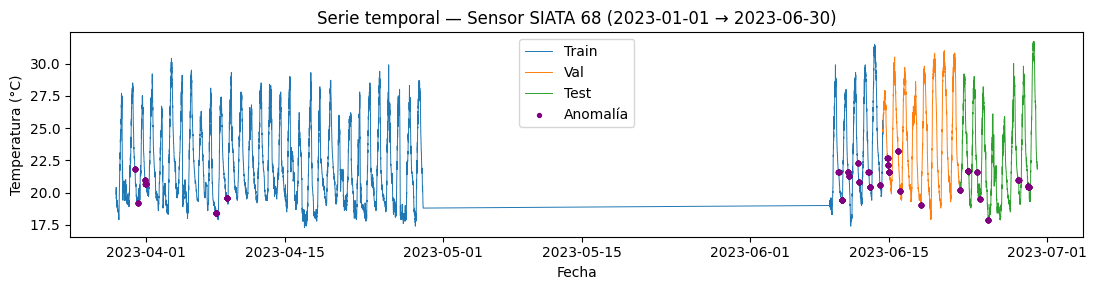

In [5]:
import matplotlib.pyplot as plt

# ── Visualización split temporal (igual que Monografia celda 16) ──────────────
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(data_train.index, data_train['t'], label='Train', linewidth=0.7)
ax.plot(data_val.index,   data_val['t'],   label='Val',   linewidth=0.7)
ax.plot(data_test.index,  data_test['t'],  label='Test',  linewidth=0.7)

# Marcar anomalías reales
_labeled = False
for df_split in [data_train, data_val, data_test]:
    anom = df_split[df_split['flag'] == 1]
    if len(anom) > 0:
        ax.scatter(anom.index, anom['t'], color='purple', s=8, zorder=5,
                   label='Anomalía' if not _labeled else '')
        _labeled = True

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title(f'Serie temporal — Sensor SIATA 68 ({config.fecha_inicio} → {config.fecha_fin})')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── Window Datasets y DataLoaders ─────────────────────────────────────────────
class WindowDataset(Dataset):
    """Dataset de ventanas deslizantes de 1 canal para PyTorch."""

    def __init__(self, data: np.ndarray, window_size: int, labels: np.ndarray = None):
        n = len(data) - window_size
        idx = np.arange(window_size)[None, :] + np.arange(n)[:, None]
        self.windows = data[idx].reshape(n, window_size).astype(np.float32)
        self.labels = None
        if labels is not None:
            self.labels = np.array(
                [int(labels[i:i + window_size].max()) for i in range(n)],
                dtype=np.float32
            )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx]


train_labels = data_train['flag'].values
val_labels   = data_val['flag'].values
test_labels  = data_test['flag'].values

train_ds = WindowDataset(train_norm, config.window_size, train_labels)
val_ds   = WindowDataset(val_norm,   config.window_size, val_labels)
test_ds  = WindowDataset(test_norm,  config.window_size, test_labels)

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True,  drop_last=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=config.batch_size, shuffle=False, drop_last=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=config.batch_size, shuffle=False, drop_last=False, num_workers=0)

print(f"Ventanas — Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
print(f"Shape de muestra: {train_ds[0].shape}")
print(f"Anomalías en train: {train_ds.labels.sum():.0f} / {len(train_ds):,}")
print(f"Anomalías en val:   {val_ds.labels.sum():.0f} / {len(val_ds):,}")
print(f"Anomalías en test:  {test_ds.labels.sum():.0f} / {len(test_ds):,}")

Ventanas — Train: 52,376 | Val: 11,214 | Test: 11,215
Shape de muestra: (12,)
Anomalías en train: 885 / 52,376
Anomalías en val:   371 / 11,214
Anomalías en test:  392 / 11,215


## 3. Funciones Helper — Reconstrucción, error y gráficas (estilo Monografia)

Equivalentes a las funciones de `Monografia_S_RNN_Mask.ipynb` adaptadas al pipeline PyTorch USAD.

In [7]:
import plotly.graph_objects as go
from sklearn.metrics import (
    precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix as sk_confusion_matrix
)


def reconstruir_serie_usad(model, data_norm_arr, config, media, std, device):
    """
    Reconstruye la serie completa desde ventanas deslizantes (stride=1) del modelo USAD.
    Promedia las reconstrucciones solapadas y aplica inversa Z-score.
    Retorna array en escala original (°C), mismo tamaño que data_norm_arr.
    """
    model.eval()
    n = len(data_norm_arr)
    w = config.window_size
    n_windows = n - w

    accumulator = np.zeros(n, dtype=np.float64)
    count        = np.zeros(n, dtype=np.float64)

    data_t = torch.FloatTensor(data_norm_arr.flatten())

    with torch.no_grad():
        for i in range(0, n_windows, config.batch_size):
            end = min(i + config.batch_size, n_windows)
            # Construir batch de ventanas
            idx_mat = np.arange(w)[None, :] + np.arange(i, end)[:, None]  # (batch, w)
            batch_np = data_norm_arr[idx_mat].astype(np.float32)           # (batch, w)
            batch = torch.FloatTensor(batch_np).to(device)

            # Reconstrucción del decoder1
            z    = model.encoder(batch)
            recon = model.decoder1(z).cpu().numpy()  # (batch, w)

            # Acumular reconstrucciones por posición
            for k, j in enumerate(range(i, end)):
                accumulator[j:j + w] += recon[k]
                count[j:j + w]        += 1

    count[count == 0] = 1
    recon_norm = accumulator / count

    # Desnormalizar (inversa Z-score)
    return recon_norm * std + media


def dataset_error_usad(df_original, t_predict_arr):
    """
    Construye df_concat con columnas: t, t_predict, error, flag.
    Equivalente a dataset_error_V2() de Monografia.
    """
    df = pd.DataFrame({
        't':         df_original['t'].values,
        'flag':      df_original['flag'].values,
        't_predict': t_predict_arr,
    }, index=df_original.index)
    df['error'] = (df['t'] - df['t_predict']) ** 2
    return df


def precision_recall_curve_plot(df_concat):
    """
    Curva Precision-Recall con punto óptimo por F1.
    Retorna umbral óptimo. Igual que Monografia celda 9.
    """
    precision_arr, recall_arr, thresholds = precision_recall_curve(
        df_concat['flag'], df_concat['error']
    )
    f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-10)
    best_idx = int(np.argmax(f1_arr[:-1]))
    umbral_opt = float(thresholds[best_idx])

    plt.figure(figsize=(6, 4))
    plt.plot(recall_arr, precision_arr, linewidth=1)
    plt.scatter(
        recall_arr[best_idx], precision_arr[best_idx],
        color='red', zorder=5,
        label=f'F1 óptimo: {f1_arr[best_idx]:.4f}\nUmbral θ = {umbral_opt:.4f}'
    )
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall — Validación')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    print(f'Umbral óptimo: {umbral_opt:.4f}')
    return umbral_opt


def plot_error_reconstruccion(df_concat, umbral, flag_pred='si'):
    """
    Plotly: error de reconstrucción por punto + línea umbral + anomalías.
    Igual que plot_error_reconstruccion() de Monografia.
    """
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df_concat.index, y=df_concat['error'],
        mode='lines', name='Error de reconstrucción',
        line=dict(color='steelblue', width=1)
    ))

    anom_real = df_concat[df_concat['flag'] == 1]
    if len(anom_real) > 0:
        fig.add_trace(go.Scatter(
            x=anom_real.index, y=anom_real['error'],
            mode='markers', name='Anomalía real',
            marker=dict(color='red', size=4)
        ))

    if flag_pred == 'si' and 'flag_pred' in df_concat.columns:
        anom_pred = df_concat[df_concat['flag_pred'] == 1]
        if len(anom_pred) > 0:
            fig.add_trace(go.Scatter(
                x=anom_pred.index, y=anom_pred['error'],
                mode='markers', name='Anomalía detectada',
                marker=dict(color='orange', symbol='x', size=6)
            ))

    fig.add_hline(
        y=umbral, line_dash='dash', line_color='black',
        annotation_text=f'Umbral θ = {umbral:.4f}',
        annotation_position='top right'
    )

    fig.update_layout(
        template='plotly_white', height=400,
        xaxis_title='Fecha', yaxis_title='Error de reconstrucción (MSE)',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig.show()


def plot_series(df_concat, plot_pred='si'):
    """
    Plotly: serie original vs reconstruida + anomalías marcadas.
    Igual que plot_series() de Monografia.
    """
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df_concat.index, y=df_concat['t'],
        mode='lines', name='Original',
        line=dict(color='steelblue', width=1)
    ))
    fig.add_trace(go.Scatter(
        x=df_concat.index, y=df_concat['t_predict'],
        mode='lines', name='Reconstruida',
        line=dict(color='orange', width=1)
    ))

    anom_real = df_concat[df_concat['flag'] == 1]
    if len(anom_real) > 0:
        fig.add_trace(go.Scatter(
            x=anom_real.index, y=anom_real['t'],
            mode='markers', name='Anomalía real',
            marker=dict(color='red', size=6, symbol='circle')
        ))

    if plot_pred == 'si' and 'flag_pred' in df_concat.columns:
        anom_pred = df_concat[df_concat['flag_pred'] == 1]
        if len(anom_pred) > 0:
            fig.add_trace(go.Scatter(
                x=anom_pred.index, y=anom_pred['t'],
                mode='markers', name='Anomalía detectada',
                marker=dict(color='purple', symbol='x', size=8)
            ))

    fig.update_layout(
        template='plotly_white', width=1000, height=400,
        xaxis_title='Fecha', yaxis_title='Temperatura (°C)',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig.show()


def metics(df_concat):
    """
    Imprime accuracy, precision, recall, f1 y matriz de confusión.
    Igual que metics() de Monografia.
    """
    y_true = df_concat['flag'].values
    y_pred = df_concat['flag_pred'].values
    print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print()
    cm = sk_confusion_matrix(y_true, y_pred)
    print('Confusion Matrix:')
    print(cm)


print('Funciones helper cargadas.')

Funciones helper cargadas.


## 4. TransferLearningAdapter — Sub-matriz del encoder pre-entrenado

In [8]:
import torch
import torch.nn as nn

USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

from usad import Encoder, Decoder, UsadModel
from utils import get_default_device, to_device

device = get_default_device()
print(f"Dispositivo: {device}")


class SubMatrixExtractor:
    """Extrae sub-matriz del encoder pre-entrenado para 1 canal."""

    def extract(self, checkpoint_path: str, w_size_new: int) -> dict:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        enc_w = checkpoint["encoder"]["linear1.weight"]  # [306, 612]
        enc_b = checkpoint["encoder"]["linear1.bias"]    # [306]

        out_rows   = w_size_new // 2
        sub_weight = enc_w[:out_rows, :w_size_new].clone()
        sub_bias   = enc_b[:out_rows].clone()

        print(f"Sub-matriz extraída: weight {sub_weight.shape}, bias {sub_bias.shape}")
        return {"weight": sub_weight, "bias": sub_bias}


class TransferLearningAdapter:
    """Construye e inicializa el nuevo modelo con pesos transferidos."""

    def __init__(self, config: Config):
        self.config    = config
        self.extractor = SubMatrixExtractor()

    def build_model(self) -> UsadModel:
        return UsadModel(w_size=self.config.w_size_new, z_size=self.config.z_size_new)

    def transfer_weights(self, model: UsadModel) -> UsadModel:
        sub = self.extractor.extract(self.config.pretrained_path, self.config.w_size_new)
        with torch.no_grad():
            model.encoder.linear1.weight.copy_(sub["weight"])
            model.encoder.linear1.bias.copy_(sub["bias"])
        print("Pesos transferidos al encoder.linear1")
        return model


adapter = TransferLearningAdapter(config)
model   = adapter.build_model()
model   = adapter.transfer_weights(model)
model   = to_device(model, device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nArquitectura (w_size={config.w_size_new}, z_size={config.z_size_new}):")
print(model)
print(f"Parámetros totales: {total_params:,}")

Dispositivo: cpu
Sub-matriz extraída: weight torch.Size([6, 12]), bias torch.Size([6])
Pesos transferidos al encoder.linear1

Arquitectura (w_size=12, z_size=4):
UsadModel(
  (encoder): Encoder(
    (linear1): Linear(in_features=12, out_features=6, bias=True)
    (linear2): Linear(in_features=6, out_features=3, bias=True)
    (linear3): Linear(in_features=3, out_features=4, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder1): Decoder(
    (linear1): Linear(in_features=4, out_features=3, bias=True)
    (linear2): Linear(in_features=3, out_features=6, bias=True)
    (linear3): Linear(in_features=6, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
  (decoder2): Decoder(
    (linear1): Linear(in_features=4, out_features=3, bias=True)
    (linear2): Linear(in_features=3, out_features=6, bias=True)
    (linear3): Linear(in_features=6, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
)
Parámetros totales: 361

## 5. Trainer — Fine-tuning con datos SIATA

ENTRENANDO: Transfer Learning + Freeze Schedule (TL+Freeze)
encoder.linear1 CONGELADO durante las primeras 20 épocas
Epoch [0], val_loss1: 1.3541, val_loss2: 1.3598
Epoch [1], val_loss1: 1.3604, val_loss2: 0.0000
Epoch [2], val_loss1: 1.3645, val_loss2: -0.4548
Epoch [3], val_loss1: 1.3689, val_loss2: -0.6837
Epoch [4], val_loss1: 1.3750, val_loss2: -0.8227
Epoch [5], val_loss1: 1.3861, val_loss2: -0.9210
Epoch [6], val_loss1: 1.4032, val_loss2: -0.9988
Epoch [7], val_loss1: 1.4256, val_loss2: -1.0658
Epoch [8], val_loss1: 1.4536, val_loss2: -1.1276
Epoch [9], val_loss1: 1.4832, val_loss2: -1.1851
Epoch [10], val_loss1: 1.5129, val_loss2: -1.2377
Epoch [11], val_loss1: 1.5433, val_loss2: -1.2875
Epoch [12], val_loss1: 1.5666, val_loss2: -1.3281
Epoch [13], val_loss1: 1.5823, val_loss2: -1.3595
Epoch [14], val_loss1: 1.5909, val_loss2: -1.3825
Epoch [15], val_loss1: 1.5939, val_loss2: -1.3988
Epoch [16], val_loss1: 1.5926, val_loss2: -1.4098
Epoch [17], val_loss1: 1.5874, val_loss2: -1.

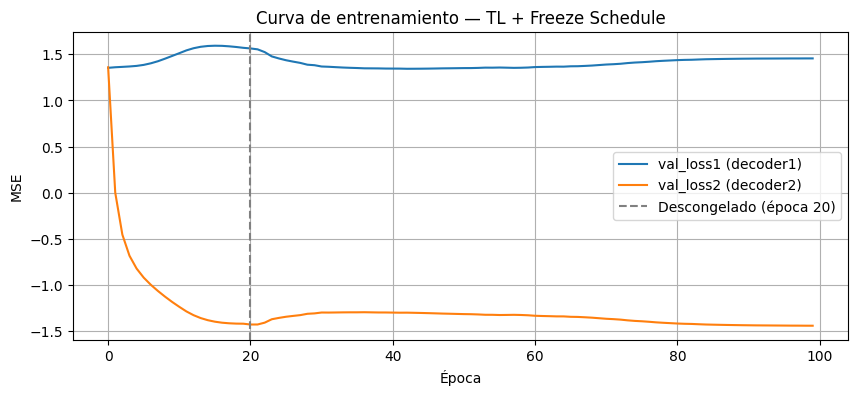

In [9]:
class USADTrainer:
    """Loop de entrenamiento USAD con freeze schedule y early stopping."""

    def __init__(self, model, config: Config, device, freeze_linear1: bool = False):
        self.model          = model
        self.config         = config
        self.device         = device
        self.freeze_linear1 = freeze_linear1
        self.history        = []
        self.best_loss      = float("inf")
        self.best_state     = None

    def _evaluate(self, val_loader, epoch_n: int) -> dict:
        outputs = []
        for batch in val_loader:
            batch = to_device(batch, self.device)
            result = self.model.validation_step(batch, epoch_n)
            outputs.append(result)
        return self.model.validation_epoch_end(outputs)

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> list:
        # Congelar encoder.linear1 al inicio si se indica freeze schedule
        if self.freeze_linear1:
            for param in self.model.encoder.linear1.parameters():
                param.requires_grad = False
            print(f"encoder.linear1 CONGELADO durante las primeras {self.config.freeze_epochs} épocas")

        opt1 = torch.optim.Adam(
            filter(lambda p: p.requires_grad,
                   list(self.model.encoder.parameters()) + list(self.model.decoder1.parameters())),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay
        )
        opt2 = torch.optim.Adam(
            filter(lambda p: p.requires_grad,
                   list(self.model.encoder.parameters()) + list(self.model.decoder2.parameters())),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay
        )

        for epoch in range(self.config.epochs):
            # Descongelar encoder.linear1 tras freeze_epochs
            if self.freeze_linear1 and epoch == self.config.freeze_epochs:
                for param in self.model.encoder.linear1.parameters():
                    param.requires_grad = True
                # Reconstruir optimizadores para incluir los parámetros recién activados
                opt1 = torch.optim.Adam(
                    list(self.model.encoder.parameters()) + list(self.model.decoder1.parameters()),
                    lr=self.config.learning_rate,
                    weight_decay=self.config.weight_decay
                )
                opt2 = torch.optim.Adam(
                    list(self.model.encoder.parameters()) + list(self.model.decoder2.parameters()),
                    lr=self.config.learning_rate,
                    weight_decay=self.config.weight_decay
                )
                print(f"  Época {epoch+1}: encoder.linear1 DESCONGELADO")

            self.model.train()
            for batch in train_loader:
                batch = to_device(batch, self.device)

                loss1, loss2 = self.model.training_step(batch, epoch + 1)
                loss1.backward()
                opt1.step()
                opt1.zero_grad()

                loss1, loss2 = self.model.training_step(batch, epoch + 1)
                loss2.backward()
                opt2.step()
                opt2.zero_grad()

            self.model.eval()
            result = self._evaluate(val_loader, epoch + 1)
            combined_loss = result["val_loss1"] + result["val_loss2"]

            if combined_loss < self.best_loss:
                self.best_loss  = combined_loss
                self.best_state = {
                    "encoder":  {k: v.cpu().clone() for k, v in self.model.encoder.state_dict().items()},
                    "decoder1": {k: v.cpu().clone() for k, v in self.model.decoder1.state_dict().items()},
                    "decoder2": {k: v.cpu().clone() for k, v in self.model.decoder2.state_dict().items()},
                }

            self.model.epoch_end(epoch, result)
            self.history.append(result)

        self.model.encoder.load_state_dict(self.best_state["encoder"])
        self.model.decoder1.load_state_dict(self.best_state["decoder1"])
        self.model.decoder2.load_state_dict(self.best_state["decoder2"])
        self.model = to_device(self.model, self.device)
        print(f"\nMejor val_loss combinado: {self.best_loss:.6f}")
        return self.history

    def plot_history(self, title_suffix=""):
        losses1 = [x["val_loss1"] for x in self.history]
        losses2 = [x["val_loss2"] for x in self.history]
        plt.figure(figsize=(10, 4))
        plt.plot(losses1, label="val_loss1 (decoder1)")
        plt.plot(losses2, label="val_loss2 (decoder2)")
        if self.freeze_linear1:
            plt.axvline(self.config.freeze_epochs, color='gray', linestyle='--',
                        label=f'Descongelado (época {self.config.freeze_epochs})')
        plt.xlabel("Época")
        plt.ylabel("MSE")
        plt.title(f"Curva de entrenamiento — {title_suffix}")
        plt.legend()
        plt.grid()
        plt.show()


# ── Entrenar modelo TL con freeze schedule ───────────────────────────────────
print("=" * 60)
print("ENTRENANDO: Transfer Learning + Freeze Schedule (TL+Freeze)")
print("=" * 60)
trainer = USADTrainer(model, config, device, freeze_linear1=True)
history = trainer.train(train_loader, val_loader)
trainer.plot_history(title_suffix="TL + Freeze Schedule")

## 6. Análisis completo — Reconstrucción, curva PR, error y series

Mismas gráficas que `Monografia_S_RNN_Mask.ipynb`: curva PR para umbral óptimo, error de reconstrucción y serie original vs reconstruida.

In [10]:
# ── Reconstrucción de la serie de ENTRENAMIENTO ───────────────────────────────
print("Reconstruyendo serie de entrenamiento...")
t_predict_train = reconstruir_serie_usad(model, train_norm, config, media, std, device)
df_concat_train = dataset_error_usad(data_train, t_predict_train)

print(f"df_concat_train — columnas: {list(df_concat_train.columns)}")
print(f"Error train — min: {df_concat_train['error'].min():.4f} | max: {df_concat_train['error'].max():.4f} | mean: {df_concat_train['error'].mean():.4f}")

Reconstruyendo serie de entrenamiento...
df_concat_train — columnas: ['t', 'flag', 't_predict', 'error']
Error train — min: 0.0000 | max: 45.8707 | mean: 5.1991


In [11]:
# ── Reconstrucción de la serie de VALIDACIÓN ─────────────────────────────────
print("Reconstruyendo serie de validación...")
t_predict_val = reconstruir_serie_usad(model, val_norm, config, media, std, device)
df_concat_val = dataset_error_usad(data_val, t_predict_val)

print(f"Error val — min: {df_concat_val['error'].min():.4f} | max: {df_concat_val['error'].max():.4f} | mean: {df_concat_val['error'].mean():.4f}")

Reconstruyendo serie de validación...
Error val — min: 0.0000 | max: 39.3451 | mean: 6.6826


ESTRATEGIAS DE UMBRAL (evaluadas en Validación)

F1-óptimo (PR): θ = 0.0649
  Precision=0.0270  Recall=1.0000  F1=0.0526

Youden's J (ROC): θ = 0.0649
  Precision=0.0270  Recall=1.0000  F1=0.0526

Percentil p99 normal: θ = 33.9933
  Precision=0.0000  Recall=0.0000  F1=0.0000

>>> Umbral seleccionado: 'F1-óptimo (PR)' θ = 0.0649  (F1 val = 0.0526)


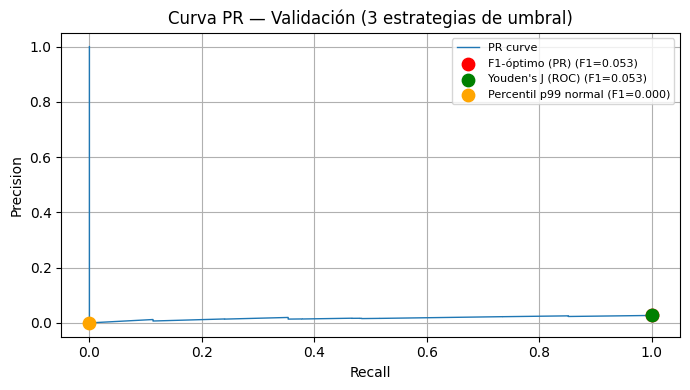


Anomalías detectadas en Val: 10474 / 11226


In [12]:
# ── Selección de umbral — 3 estrategias (nueva en v3) ────────────────────────
from sklearn.metrics import precision_recall_curve, roc_curve

precision_arr, recall_arr, thresholds_pr = precision_recall_curve(
    df_concat_val['flag'], df_concat_val['error']
)
fpr_arr, tpr_arr, thresholds_roc = roc_curve(
    df_concat_val['flag'], df_concat_val['error']
)

# 1. F1-óptimo (mismo que v2)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-10)
best_f1_idx = int(np.argmax(f1_arr[:-1]))
umbral_f1   = float(thresholds_pr[best_f1_idx])

# 2. Youden's J (maximiza TPR - FPR — mejor balance sensibilidad/especificidad)
j_scores      = tpr_arr - fpr_arr
best_j_idx    = int(np.argmax(j_scores))
umbral_youden = float(thresholds_roc[best_j_idx])

# 3. Percentil p99 sobre scores de ventanas normales en validación
scores_val_normal = df_concat_val[df_concat_val['flag'] == 0]['error'].values
umbral_p99        = float(np.percentile(scores_val_normal, 99))

print("=" * 55)
print("ESTRATEGIAS DE UMBRAL (evaluadas en Validación)")
print("=" * 55)

resultados_umbral = []
for nombre, umbral_eval in [("F1-óptimo (PR)",        umbral_f1),
                             ("Youden's J (ROC)",       umbral_youden),
                             ("Percentil p99 normal",   umbral_p99)]:
    y_pred_eval = (df_concat_val['error'] >= umbral_eval).astype(int)
    p = precision_score(df_concat_val['flag'], y_pred_eval, zero_division=0)
    r = recall_score(df_concat_val['flag'],    y_pred_eval, zero_division=0)
    f = f1_score(df_concat_val['flag'],        y_pred_eval, zero_division=0)
    print(f"\n{nombre}: θ = {umbral_eval:.4f}")
    print(f"  Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")
    resultados_umbral.append({"nombre": nombre, "umbral": umbral_eval,
                               "precision": p, "recall": r, "f1": f})

# Seleccionar el umbral con mejor F1 en validación
best_row = max(resultados_umbral, key=lambda x: x["f1"])
umbral   = best_row["umbral"]
print(f"\n>>> Umbral seleccionado: '{best_row['nombre']}' θ = {umbral:.4f}  (F1 val = {best_row['f1']:.4f})")

# Visualización curva PR con los 3 umbrales marcados
plt.figure(figsize=(7, 4))
plt.plot(recall_arr, precision_arr, linewidth=1, label="PR curve")
colores = {"F1-óptimo (PR)": "red", "Youden's J (ROC)": "green", "Percentil p99 normal": "orange"}
for r_d in resultados_umbral:
    idx = np.argmin(np.abs(thresholds_pr - r_d["umbral"]))
    plt.scatter(recall_arr[idx], precision_arr[idx], s=80,
                color=colores[r_d["nombre"]], zorder=5,
                label=f'{r_d["nombre"]} (F1={r_d["f1"]:.3f})')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Curva PR — Validación (3 estrategias de umbral)")
plt.legend(fontsize=8); plt.grid(); plt.tight_layout(); plt.show()

# Asignar flag_pred en validación con umbral elegido
df_concat_val['flag_pred'] = (df_concat_val['error'] >= umbral).astype(int)
print(f"\nAnomalías detectadas en Val: {df_concat_val['flag_pred'].sum()} / {len(df_concat_val)}")

In [13]:
# ── Error de reconstrucción — Validación ─────────────────────────────────────
print("Error de reconstrucción — Validación (sin flag_pred):")
plot_error_reconstruccion(df_concat_val, umbral, flag_pred='no')

Error de reconstrucción — Validación (sin flag_pred):


In [14]:
# ── Serie original vs reconstruida — Validación ──────────────────────────────
print("Serie original vs reconstruida — Validación:")
plot_series(df_concat_val, plot_pred='no')

Serie original vs reconstruida — Validación:


In [15]:
# ── Reconstrucción de la serie de TEST ───────────────────────────────────────
print("Reconstruyendo serie de test...")
t_predict_test = reconstruir_serie_usad(model, test_norm, config, media, std, device)
df_concat_test = dataset_error_usad(data_test, t_predict_test)

# Asignar flag_pred en test con el umbral de validación
df_concat_test['flag_pred'] = (df_concat_test['error'] >= umbral).astype(int)

print(f"Error test — min: {df_concat_test['error'].min():.4f} | max: {df_concat_test['error'].max():.4f} | mean: {df_concat_test['error'].mean():.4f}")
print(f"Anomalías detectadas en Test: {df_concat_test['flag_pred'].sum()} / {len(df_concat_test)}")

Reconstruyendo serie de test...
Error test — min: 0.0000 | max: 48.6223 | mean: 5.8122
Anomalías detectadas en Test: 10045 / 11227


In [16]:
# ── Error de reconstrucción — Test ───────────────────────────────────────────
print("Error de reconstrucción — Test (con flag_pred):")
plot_error_reconstruccion(df_concat_test, umbral, flag_pred='si')

Error de reconstrucción — Test (con flag_pred):


In [17]:
# ── Serie original vs reconstruida — Test ────────────────────────────────────
print("Serie original vs reconstruida — Test (con anomalías detectadas):")
plot_series(df_concat_test, plot_pred='si')

Serie original vs reconstruida — Test (con anomalías detectadas):


In [18]:
# ── Métricas finales — Test ───────────────────────────────────────────────────
print("=" * 40)
print("MÉTRICAS FINALES — TEST")
print("=" * 40)
metics(df_concat_test)
print(f"\nUmbral θ utilizado: {umbral:.4f}")
print(f"Media (Z-score): {media:.2f}°C")
print(f"Std   (Z-score): {std:.2f}°C")

MÉTRICAS FINALES — TEST
Accuracy:  0.1333
Precision: 0.0314
Recall:    1.0000
F1-Score:  0.0608

Confusion Matrix:
[[1182 9730]
 [   0  315]]

Umbral θ utilizado: 0.0649
Media (Z-score): 22.11°C
Std   (Z-score): 3.09°C


## 7. Evaluación complementaria — ROC, histogramas y matrices de confusión

In [19]:
import seaborn as sns
from sklearn.metrics import (
    roc_curve, roc_auc_score, classification_report
)


class AnomalyScorer:
    """Calcula scores de anomalía por ventana con el modelo entrenado."""

    def __init__(self, model, config: Config, device):
        self.model  = model
        self.config = config
        self.device = device

    def score(self, loader: DataLoader) -> np.ndarray:
        self.model.eval()
        scores = []
        with torch.no_grad():
            for batch in loader:
                batch = to_device(batch, self.device)
                w1 = self.model.decoder1(self.model.encoder(batch))
                w2 = self.model.decoder2(self.model.encoder(w1))
                s  = (
                    self.config.alpha * torch.mean((batch - w1) ** 2, dim=1) +
                    self.config.beta  * torch.mean((batch - w2) ** 2, dim=1)
                )
                scores.append(s.cpu().numpy())
        return np.concatenate(scores)


class MetricsEvaluator:
    """Calcula y visualiza métricas de evaluación por ventana."""

    def plot_roc(self, labels, scores, split_name):
        fpr, tpr, tr = roc_curve(labels, scores)
        auc = roc_auc_score(labels, scores)
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot(fpr, 1 - fpr, "r:", label="Random")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.title(f"Curva ROC — {split_name}")
        plt.legend(loc=4); plt.grid(); plt.show()
        return auc

    def plot_confusion_matrix(self, y_true, y_pred, split_name):
        cm = sk_confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal", "Anomalía"],
                    yticklabels=["Normal", "Anomalía"])
        plt.title(f"Matriz de Confusión — {split_name}")
        plt.ylabel("Real"); plt.xlabel("Predicho"); plt.show()

    def evaluate(self, y_true, y_pred, scores, split_name):
        f1  = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        pre = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float("nan")
        print(f"\n=== Métricas — {split_name} ===")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Precision: {pre:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  AUC-ROC:   {auc:.4f}")
        print()
        print(classification_report(y_true, y_pred, target_names=["Normal", "Anomalía"], zero_division=0))
        self.plot_confusion_matrix(y_true, y_pred, split_name)
        return {"f1": f1, "accuracy": acc, "auc": auc, "precision": pre, "recall": rec}

    def plot_histogram(self, labels, scores, threshold, split_name):
        plt.figure(figsize=(10, 4))
        plt.hist(scores[labels == 0], bins=50, alpha=0.7, color="#82E0AA", label="Normal")
        plt.hist(scores[labels == 1], bins=50, alpha=0.7, color="#EC7063", label="Anomalía")
        plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold={threshold:.4f}")
        plt.title(f"Distribución de Anomaly Scores — {split_name}")
        plt.xlabel("Anomaly Score"); plt.ylabel("Frecuencia")
        plt.legend(); plt.grid(); plt.show()


scorer    = AnomalyScorer(model, config, device)
evaluator = MetricsEvaluator()

scores_train = scorer.score(train_loader)
scores_val   = scorer.score(val_loader)
scores_test  = scorer.score(test_loader)

# Usar umbral seleccionado
y_pred_train = (scores_train >= umbral).astype(int)
y_pred_val   = (scores_val   >= umbral).astype(int)
y_pred_test  = (scores_test  >= umbral).astype(int)

print(f"Umbral θ = {umbral:.4f}")

Umbral θ = 0.0649


=== Entrenamiento ===


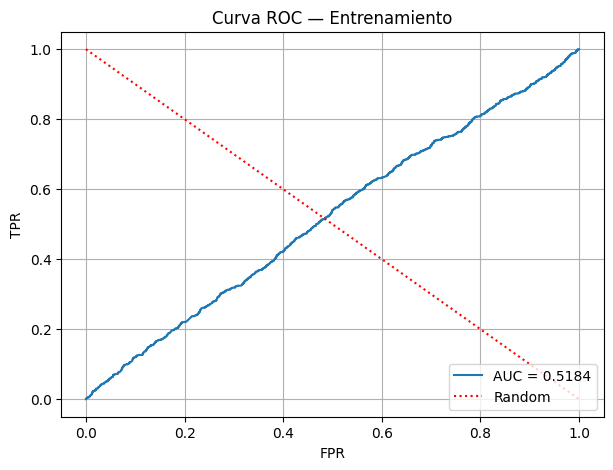

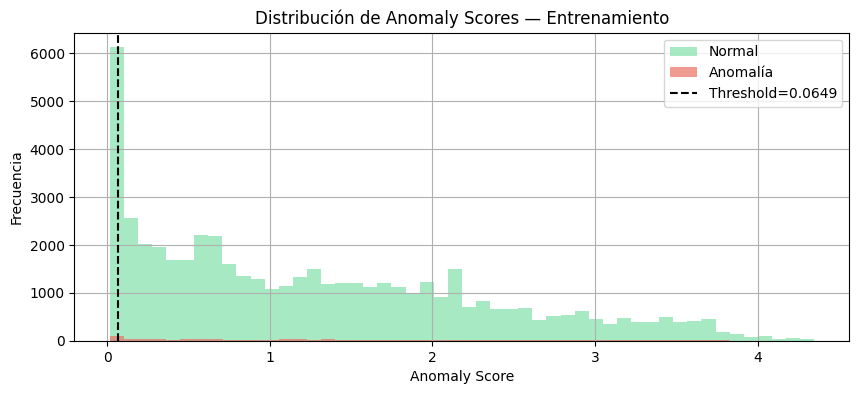


=== Métricas — Entrenamiento ===
  F1-Score:  0.0329
  Precision: 0.0168
  Recall:    0.9028
  Accuracy:  0.1035
  AUC-ROC:   0.5184

              precision    recall  f1-score   support

      Normal       0.98      0.09      0.16     51491
    Anomalía       0.02      0.90      0.03       885

    accuracy                           0.10     52376
   macro avg       0.50      0.50      0.10     52376
weighted avg       0.97      0.10      0.16     52376



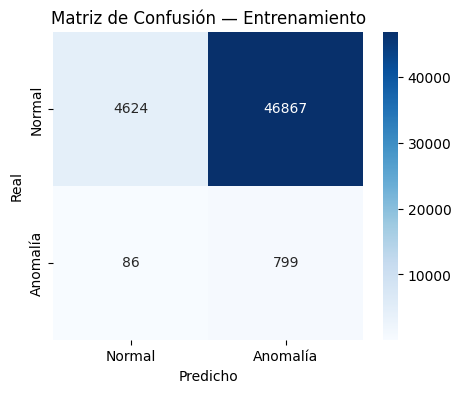

In [20]:
# ROC + histograma + métricas — Entrenamiento
print("=== Entrenamiento ===")
evaluator.plot_roc(train_ds.labels, scores_train, "Entrenamiento")
evaluator.plot_histogram(train_ds.labels, scores_train, umbral, "Entrenamiento")
metrics_train = evaluator.evaluate(train_ds.labels, y_pred_train, scores_train, "Entrenamiento")

=== Validación ===


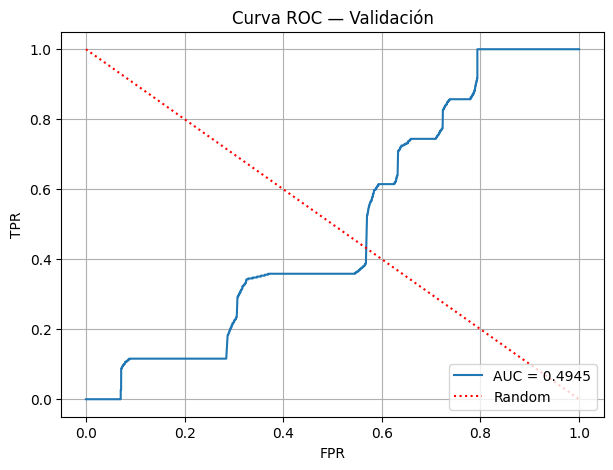

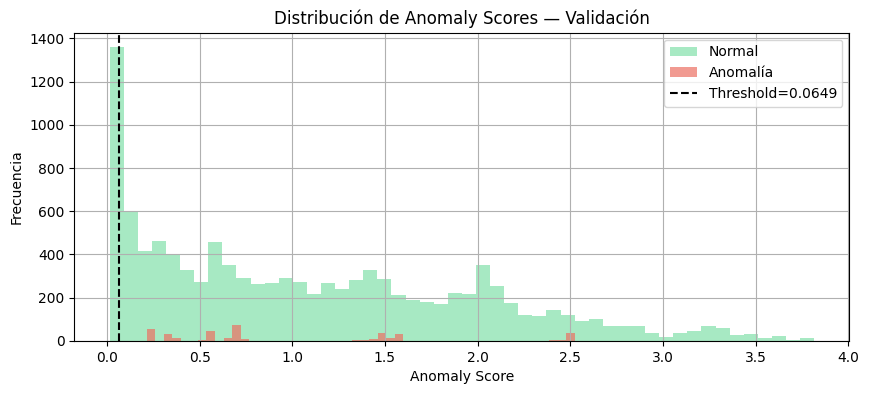


=== Métricas — Validación ===
  F1-Score:  0.0711
  Precision: 0.0369
  Recall:    1.0000
  Accuracy:  0.1362
  AUC-ROC:   0.4945

              precision    recall  f1-score   support

      Normal       1.00      0.11      0.19     10843
    Anomalía       0.04      1.00      0.07       371

    accuracy                           0.14     11214
   macro avg       0.52      0.55      0.13     11214
weighted avg       0.97      0.14      0.19     11214



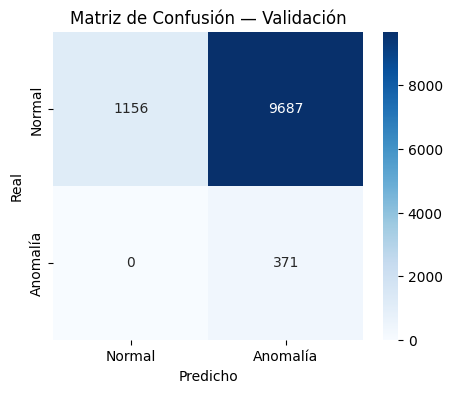

In [21]:
# ROC + histograma + métricas — Validación
print("=== Validación ===")
evaluator.plot_roc(val_ds.labels, scores_val, "Validación")
evaluator.plot_histogram(val_ds.labels, scores_val, umbral, "Validación")
metrics_val = evaluator.evaluate(val_ds.labels, y_pred_val, scores_val, "Validación")

=== Test ===


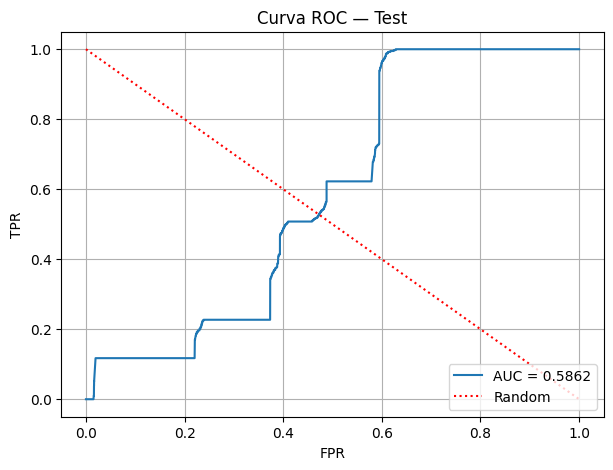

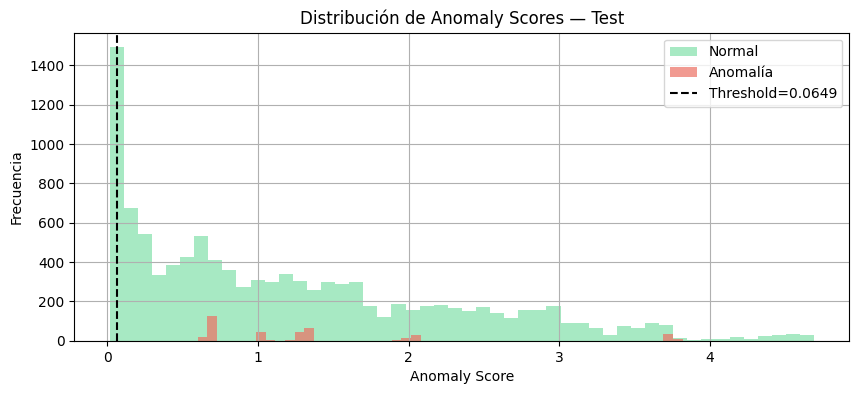


=== Métricas — Test ===
  F1-Score:  0.0740
  Precision: 0.0384
  Recall:    1.0000
  Accuracy:  0.1257
  AUC-ROC:   0.5862

              precision    recall  f1-score   support

      Normal       1.00      0.09      0.17     10823
    Anomalía       0.04      1.00      0.07       392

    accuracy                           0.13     11215
   macro avg       0.52      0.55      0.12     11215
weighted avg       0.97      0.13      0.17     11215



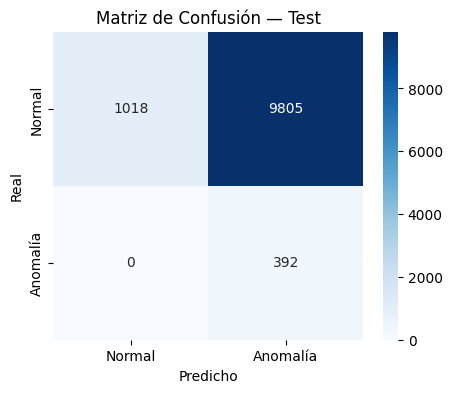

In [22]:
# ROC + histograma + métricas — Test
print("=== Test ===")
evaluator.plot_roc(test_ds.labels, scores_test, "Test")
evaluator.plot_histogram(test_ds.labels, scores_test, umbral, "Test")
metrics_test = evaluator.evaluate(test_ds.labels, y_pred_test, scores_test, "Test")

## 8. Resumen comparativo y Conclusiones

In [23]:
summary = pd.DataFrame({
    "Split":     ["Entrenamiento", "Validación", "Test"],
    "F1-Score":  [metrics_train["f1"],        metrics_val["f1"],        metrics_test["f1"]],
    "Precision": [metrics_train["precision"],  metrics_val["precision"],  metrics_test["precision"]],
    "Recall":    [metrics_train["recall"],     metrics_val["recall"],     metrics_test["recall"]],
    "Accuracy":  [metrics_train["accuracy"],   metrics_val["accuracy"],   metrics_test["accuracy"]],
    "AUC-ROC":   [metrics_train["auc"],        metrics_val["auc"],        metrics_test["auc"]],
}).set_index("Split").round(4)

print("=" * 65)
print("RESUMEN DE MÉTRICAS — Transfer Learning USAD→SIATA 68 (v3)")
print("=" * 65)
print(summary.to_string())
print()
print(f"Normalización:  Z-score | media={media:.2f}°C | std={std:.2f}°C")
print(f"Rango:          {config.fecha_inicio} → {config.fecha_fin}")
print(f"Umbral θ:       {umbral:.4f} (mejor estrategia en validación)")
print(f"Bottleneck:     z_size={config.z_size_new} (compresión {config.w_size_new/config.z_size_new:.1f}x)")
print(f"Freeze epochs:  {config.freeze_epochs}")
print(f"Splits:         {len(data_train):,} / {len(data_val):,} / {len(data_test):,} (70/15/15%)")
print()
print("Comparación v2 vs v3 (Test):")
print("  v2: AUC=0.4377 | F1=0.0701 | Precision=0.0291 | umbral=0.0030")
print(f"  v3: AUC={metrics_test['auc']:.4f} | F1={metrics_test['f1']:.4f} | Precision={metrics_test['precision']:.4f} | umbral={umbral:.4f}")

RESUMEN DE MÉTRICAS — Transfer Learning USAD→SIATA 68 (v3)
               F1-Score  Precision  Recall  Accuracy  AUC-ROC
Split                                                        
Entrenamiento    0.0329     0.0168  0.9028    0.1035   0.5184
Validación       0.0711     0.0369  1.0000    0.1362   0.4945
Test             0.0740     0.0384  1.0000    0.1257   0.5862

Normalización:  Z-score | media=22.11°C | std=3.09°C
Rango:          2023-01-01 → 2023-06-30
Umbral θ:       0.0649 (mejor estrategia en validación)
Bottleneck:     z_size=4 (compresión 3.0x)
Freeze epochs:  20
Splits:         52,388 / 11,226 / 11,227 (70/15/15%)

Comparación v2 vs v3 (Test):
  v2: AUC=0.4377 | F1=0.0701 | Precision=0.0291 | umbral=0.0030
  v3: AUC=0.5862 | F1=0.0740 | Precision=0.0384 | umbral=0.0649


## 9. Ablation Study — Scratch vs TL vs TL+Freeze

Comparación de tres estrategias de inicialización para validar que el transfer learning aporta valor:
- **Scratch:** modelo inicializado aleatoriamente (sin pesos pre-entrenados)
- **TL (sin freeze):** pesos transferidos, todos los parámetros libres desde época 1
- **TL + Freeze:** pesos transferidos + `encoder.linear1` congelado las primeras 20 épocas (modelo principal de v3)

ENTRENANDO: Scratch (sin Transfer Learning)
Epoch [0], val_loss1: 1.3583, val_loss2: 1.3696
Epoch [1], val_loss1: 1.3685, val_loss2: 0.0000
Epoch [2], val_loss1: 1.3763, val_loss2: -0.4610
Epoch [3], val_loss1: 1.3836, val_loss2: -0.6950
Epoch [4], val_loss1: 1.3911, val_loss2: -0.8383
Epoch [5], val_loss1: 1.3989, val_loss2: -0.9367
Epoch [6], val_loss1: 1.4074, val_loss2: -1.0096
Epoch [7], val_loss1: 1.4165, val_loss2: -1.0670
Epoch [8], val_loss1: 1.4262, val_loss2: -1.1142
Epoch [9], val_loss1: 1.4368, val_loss2: -1.1546
Epoch [10], val_loss1: 1.4481, val_loss2: -1.1901
Epoch [11], val_loss1: 1.4600, val_loss2: -1.2222
Epoch [12], val_loss1: 1.4726, val_loss2: -1.2516
Epoch [13], val_loss1: 1.4855, val_loss2: -1.2789
Epoch [14], val_loss1: 1.4988, val_loss2: -1.3046
Epoch [15], val_loss1: 1.5123, val_loss2: -1.3288
Epoch [16], val_loss1: 1.5257, val_loss2: -1.3516
Epoch [17], val_loss1: 1.5390, val_loss2: -1.3731
Epoch [18], val_loss1: 1.5520, val_loss2: -1.3935
Epoch [19], val_lo

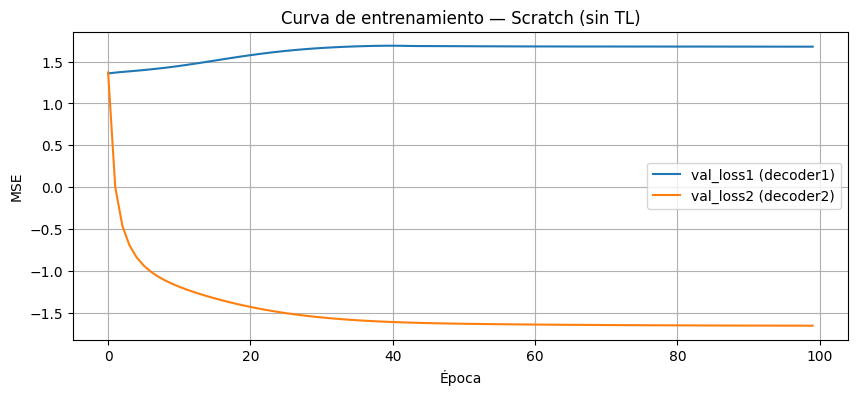


ENTRENANDO: Transfer Learning sin freeze (TL puro)
Sub-matriz extraída: weight torch.Size([6, 12]), bias torch.Size([6])
Pesos transferidos al encoder.linear1
Epoch [0], val_loss1: 1.3583, val_loss2: 1.3696
Epoch [1], val_loss1: 1.3685, val_loss2: 0.0000
Epoch [2], val_loss1: 1.3763, val_loss2: -0.4610
Epoch [3], val_loss1: 1.3836, val_loss2: -0.6950
Epoch [4], val_loss1: 1.3911, val_loss2: -0.8383
Epoch [5], val_loss1: 1.3989, val_loss2: -0.9367
Epoch [6], val_loss1: 1.4074, val_loss2: -1.0096
Epoch [7], val_loss1: 1.4165, val_loss2: -1.0670
Epoch [8], val_loss1: 1.4262, val_loss2: -1.1142
Epoch [9], val_loss1: 1.4368, val_loss2: -1.1546
Epoch [10], val_loss1: 1.4481, val_loss2: -1.1901
Epoch [11], val_loss1: 1.4600, val_loss2: -1.2222
Epoch [12], val_loss1: 1.4726, val_loss2: -1.2516
Epoch [13], val_loss1: 1.4855, val_loss2: -1.2789
Epoch [14], val_loss1: 1.4988, val_loss2: -1.3046
Epoch [15], val_loss1: 1.5123, val_loss2: -1.3288
Epoch [16], val_loss1: 1.5257, val_loss2: -1.3516
Ep

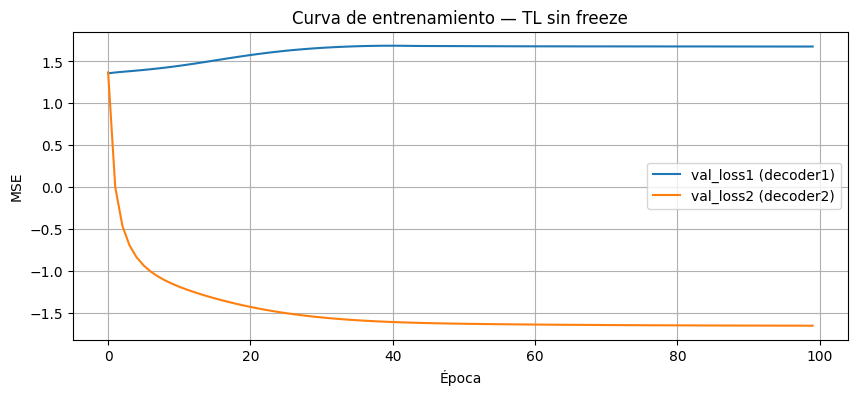

In [24]:
def _get_best_threshold(model_eval, val_loader_eval, val_ds_eval):
    """Calcula el mejor umbral (F1-PR) sobre validación para un modelo dado."""
    sc_tmp = AnomalyScorer(model_eval, config, device)
    sc_val = sc_tmp.score(val_loader_eval)
    prec, rec, thr = precision_recall_curve(val_ds_eval.labels, sc_val)
    f1s = 2 * prec * rec / (prec + rec + 1e-10)
    best_thr = float(thr[np.argmax(f1s[:-1])])
    return sc_tmp, best_thr


def _run_ablation(model_eval, label):
    sc_tmp, thr_tmp = _get_best_threshold(model_eval, val_loader, val_ds)
    sc_val  = sc_tmp.score(val_loader)
    sc_test = sc_tmp.score(test_loader)
    y_pred  = (sc_test >= thr_tmp).astype(int)
    auc_val = roc_auc_score(val_ds.labels,  sc_val)
    auc_tst = roc_auc_score(test_ds.labels, sc_test)
    f1_tst  = f1_score(test_ds.labels,      y_pred, zero_division=0)
    pre_tst = precision_score(test_ds.labels, y_pred, zero_division=0)
    rec_tst = recall_score(test_ds.labels,  y_pred, zero_division=0)
    print(f"  {label}: θ={thr_tmp:.4f} | Val AUC={auc_val:.4f} | Test AUC={auc_tst:.4f} | F1={f1_tst:.4f} | Prec={pre_tst:.4f} | Rec={rec_tst:.4f}")
    return {"modelo": label, "umbral": thr_tmp, "val_auc": auc_val,
            "test_auc": auc_tst, "test_f1": f1_tst, "test_precision": pre_tst, "test_recall": rec_tst}


torch.manual_seed(config.random_seed)

# ── Modelo 1: Scratch (sin pesos pre-entrenados) ──────────────────────────────
print("=" * 60)
print("ENTRENANDO: Scratch (sin Transfer Learning)")
print("=" * 60)
model_scratch = UsadModel(w_size=config.w_size_new, z_size=config.z_size_new)
model_scratch = to_device(model_scratch, device)
trainer_scratch = USADTrainer(model_scratch, config, device, freeze_linear1=False)
trainer_scratch.train(train_loader, val_loader)
trainer_scratch.plot_history(title_suffix="Scratch (sin TL)")

# ── Modelo 2: TL sin freeze ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ENTRENANDO: Transfer Learning sin freeze (TL puro)")
print("=" * 60)
torch.manual_seed(config.random_seed)
model_tl = adapter.build_model()
model_tl  = adapter.transfer_weights(model_tl)
model_tl  = to_device(model_tl, device)
trainer_tl = USADTrainer(model_tl, config, device, freeze_linear1=False)
trainer_tl.train(train_loader, val_loader)
trainer_tl.plot_history(title_suffix="TL sin freeze")


COMPARATIVA ABLATION STUDY
  Scratch: θ=0.0035 | Val AUC=0.2424 | Test AUC=0.3556 | F1=0.0679 | Prec=0.0352 | Rec=1.0000
  TL (sin freeze): θ=0.0036 | Val AUC=0.2423 | Test AUC=0.3554 | F1=0.0679 | Prec=0.0352 | Rec=1.0000
  TL + Freeze  ★: θ=0.2138 | Val AUC=0.4945 | Test AUC=0.5862 | F1=0.0836 | Prec=0.0436 | Rec=1.0000

                 val_auc  test_auc  test_f1  test_precision  test_recall  umbral
modelo                                                                          
Scratch           0.2424    0.3556   0.0679          0.0352          1.0  0.0035
TL (sin freeze)   0.2423    0.3554   0.0679          0.0352          1.0  0.0036
TL + Freeze  ★    0.4945    0.5862   0.0836          0.0436          1.0  0.2138


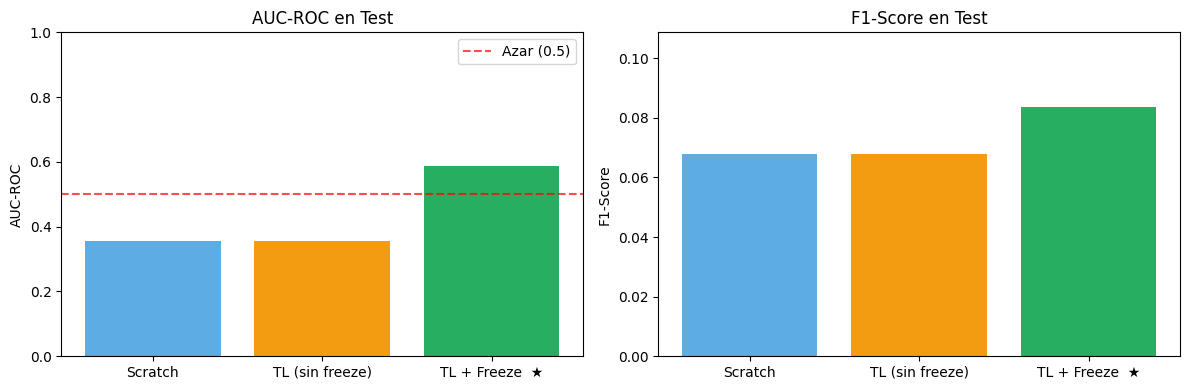


Conclusión: el mejor modelo por AUC-ROC es 'TL + Freeze  ★' con AUC=0.5862
TL + Freeze vs Scratch: AUC mejora en 64.8%


In [25]:
# ── Tabla comparativa de los 3 modelos ───────────────────────────────────────
print("\n" + "=" * 60)
print("COMPARATIVA ABLATION STUDY")
print("=" * 60)

ablation_results = []
for m, lbl in [(model_scratch, "Scratch"),
               (model_tl,      "TL (sin freeze)"),
               (model,         "TL + Freeze  ★")]:
    ablation_results.append(_run_ablation(m, lbl))

df_ablation = pd.DataFrame(ablation_results).set_index("modelo").round(4)
print()
print(df_ablation[["val_auc", "test_auc", "test_f1", "test_precision", "test_recall", "umbral"]].to_string())

# ── Visualización comparativa AUC y F1 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
modelos = df_ablation.index.tolist()
colores = ["#5DADE2", "#F39C12", "#27AE60"]

axes[0].bar(modelos, df_ablation["test_auc"], color=colores)
axes[0].axhline(0.5, linestyle='--', color='red', alpha=0.7, label='Azar (0.5)')
axes[0].set_title("AUC-ROC en Test"); axes[0].set_ylabel("AUC-ROC")
axes[0].set_ylim(0, 1); axes[0].legend()

axes[1].bar(modelos, df_ablation["test_f1"], color=colores)
axes[1].set_title("F1-Score en Test"); axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, max(df_ablation["test_f1"].max() * 1.3, 0.1))

plt.tight_layout(); plt.show()

# ── Conclusión automática ─────────────────────────────────────────────────────
best = df_ablation["test_auc"].idxmax()
print(f"\nConclusión: el mejor modelo por AUC-ROC es '{best}' con AUC={df_ablation.loc[best,'test_auc']:.4f}")
tl_freeze_auc = df_ablation.loc["TL + Freeze  ★", "test_auc"]
scratch_auc   = df_ablation.loc["Scratch",         "test_auc"]
mejora = (tl_freeze_auc - scratch_auc) / max(scratch_auc, 1e-6) * 100
print(f"TL + Freeze vs Scratch: AUC {'mejora' if mejora > 0 else 'no mejora'} en {abs(mejora):.1f}%")

## 10. Guardar modelo fine-tuneado (v3)

In [26]:
save_path = "modelos/usad/model_siata_68_transfer_v3.pth"
torch.save({
    "encoder":   model.encoder.state_dict(),
    "decoder1":  model.decoder1.state_dict(),
    "decoder2":  model.decoder2.state_dict(),
    "config":    config.__dict__,
    "threshold": umbral,
    "media":     media,
    "std":       std,
    "metrics":   {"train": metrics_train, "val": metrics_val, "test": metrics_test},
    "ablation":  ablation_results if 'ablation_results' in dir() else None,
}, save_path)
print(f"Modelo guardado en: {save_path}")
print(f"  umbral:    {umbral:.4f}")
print(f"  media:     {media:.2f}")
print(f"  std:       {std:.2f}")
print(f"  z_size:    {config.z_size_new}")
print(f"  lr:        {config.learning_rate}")

Modelo guardado en: modelos/usad/model_siata_68_transfer_v3.pth
  umbral:    0.0649
  media:     22.11
  std:       3.09
  z_size:    4
  lr:        0.0001
